In [2]:
%matplotlib inline

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import xarray

EMEP MSC-W modelled air concentrations and depositions  
https://www.emep.int/mscw/mscw_ydata.html  
Latest available data - Yearly values for year 2022 (2022 emissions)  
https://thredds.met.no/thredds/catalog/data/EMEP/2024_Reporting/catalog.html?dataset=EMEP/2024_Reporting/EMEP01_rv5.3_year.2023met_2022emis.nc

In [4]:
atmDepFile = 'EMEPData\\EMEP01_rv5.3_year.2023met_2022emis.nc'
outFile='Data\\AtmDep2022.geojson'

In [5]:
ds = xarray.open_dataset(atmDepFile)

In [6]:
# reduced range -> focusing on Lithuania
lon_index = (ds.lon>=20.5) & (ds.lon<=27.5)
lat_index = (ds.lat>=53.5) & (ds.lat<=57)
#lon_index = (ds.lon>=20) | (ds.lon<=28)
#lat_index = (ds.lat>=53) | (ds.lat<=57)
longitudes_cell_center = ds.lon[lon_index]
latitudes_cell_center = ds.lat[lat_index]
#longitudes_grid, latitudes_grid = np.meshgrid(longitudes, latitudes)
delta_lon = float(longitudes_cell_center[1]-longitudes_cell_center[0])
delta_lat = float(latitudes_cell_center[1]-latitudes_cell_center[0])
longitudes_cell_borders = np.append(longitudes_cell_center - delta_lon/2,[longitudes_cell_center[-1]+delta_lon/2])
latitudes_cell_borders = np.append(latitudes_cell_center - delta_lat/2,[latitudes_cell_center[-1]+delta_lat/2])

In [7]:
# [(old_id, new_id)]
variables = [
    ("precipitation","WDEP_PREC"),
    ("NH4_dry","DDEP_RDN_m2Grid"),
    ("NH4_wet","WDEP_RDN"),
    ("NO3_dry","DDEP_OXN_m2Grid"),
    ("NO3_wet","WDEP_OXN")
]

In [8]:
import geopandas as gpd
from shapely.geometry import Polygon
lon, lat = np.meshgrid(longitudes_cell_center, latitudes_cell_center)
#polygon_geom = Polygon(zip(lon_point_list, lat_point_list))
#crs = {'init': 'epsg:4326'}
longitudes_rect = np.moveaxis(np.array([lon-delta_lon/2,lon+delta_lon/2,lon+delta_lon/2,lon-delta_lon/2]),0,-1)
latitudes_rect = np.moveaxis(np.array([lat-delta_lat/2,lat-delta_lat/2,lat+delta_lat/2,lat+delta_lat/2]),0,-1)
longitudes_rect = longitudes_rect.reshape((longitudes_rect.shape[0]*longitudes_rect.shape[1]),longitudes_rect.shape[2])
latitudes_rect = latitudes_rect.reshape((latitudes_rect.shape[0]*latitudes_rect.shape[1]),latitudes_rect.shape[2])
fishnet = np.dstack([longitudes_rect,latitudes_rect])
fishnet_polygons = [Polygon(p) for p in fishnet]

In [9]:
gdf = gpd.GeoDataFrame(geometry  = fishnet_polygons, crs="EPSG:4326")
for v in variables:
    df = ds[v[1]]
    gdf[v[0]] =  np.array(df[0][lat_index,:][:,lon_index]).flatten()
# convert to LKS-94 Lithuania
gdf = gdf.to_crs('EPSG:3346')
gdf['Shape_Area']=gdf.area
gdf.to_file(outFile, driver='GeoJSON')


In [10]:
import fiona; fiona.supported_drivers

{'AeronavFAA': 'r',
 'ARCGEN': 'r',
 'BNA': 'rw',
 'DXF': 'rw',
 'CSV': 'raw',
 'OpenFileGDB': 'r',
 'FlatGeobuf': 'r',
 'ESRIJSON': 'r',
 'ESRI Shapefile': 'raw',
 'GeoJSON': 'raw',
 'GeoJSONSeq': 'rw',
 'GPKG': 'raw',
 'GML': 'rw',
 'OGR_GMT': 'rw',
 'GPX': 'rw',
 'GPSTrackMaker': 'rw',
 'Idrisi': 'r',
 'MapInfo File': 'raw',
 'DGN': 'raw',
 'PCIDSK': 'rw',
 'OGR_PDS': 'r',
 'S57': 'r',
 'SEGY': 'r',
 'SUA': 'r',
 'TopoJSON': 'r'}

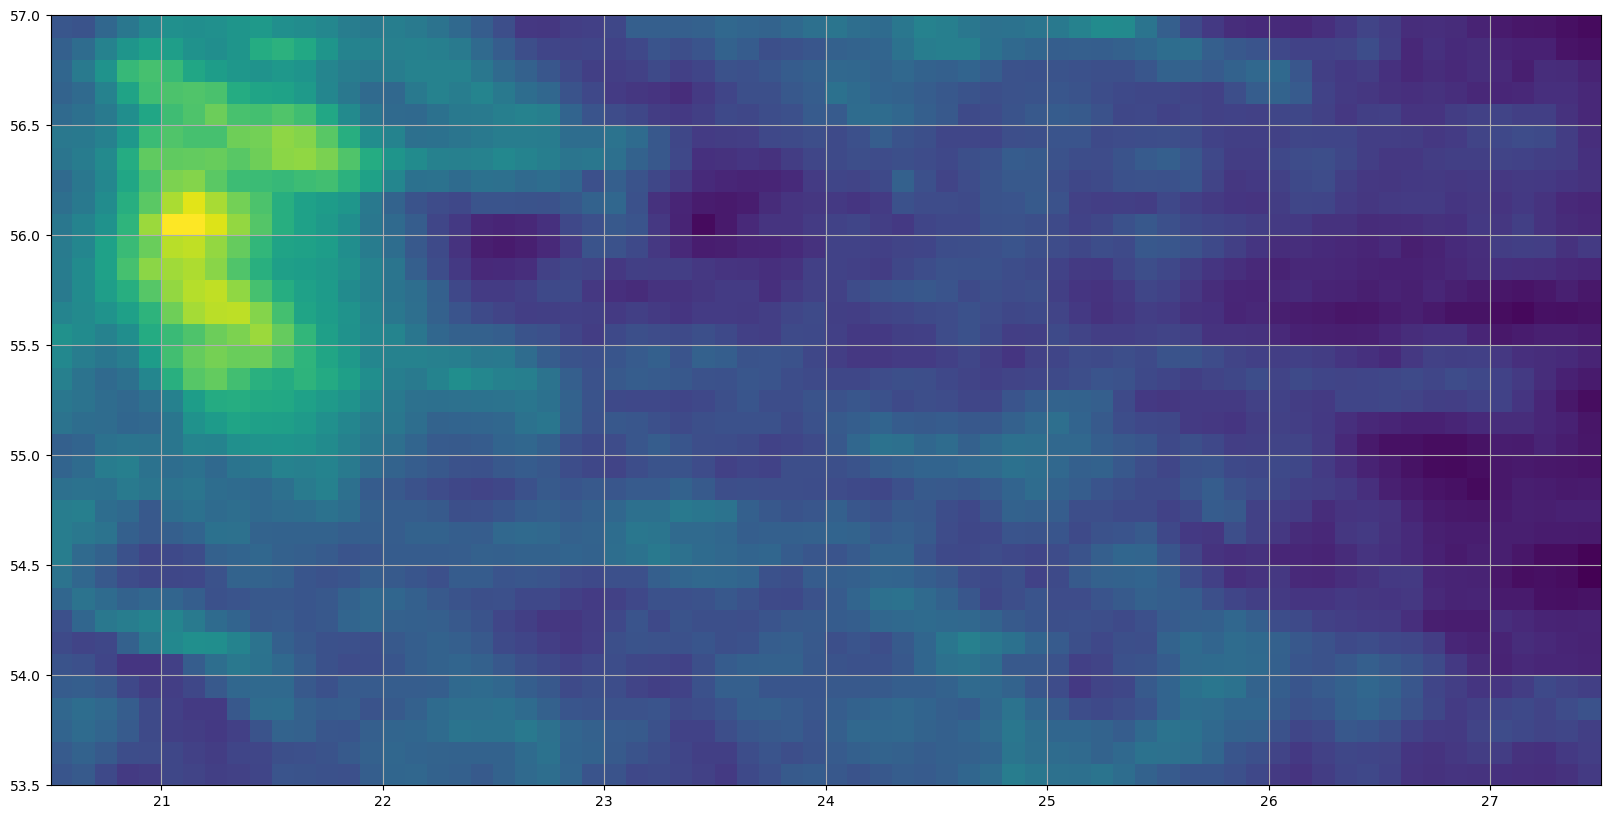

In [11]:
fig, ax = plt.subplots(figsize=(20,10))
ax.pcolormesh(longitudes_cell_borders, latitudes_cell_borders, df[0][lat_index,:][:,lon_index],
              shading='flat' )
ax.grid()
plt.show()

In [12]:
ds.close()